# ch279 — Confidence Intervals

*(Directly follows ch277–278; uses sampling distribution from ch275)*

## 1. What a Confidence Interval Is

A 95% confidence interval is a procedure. If you repeated the sampling and interval construction process 100 times, approximately 95 of those intervals would contain the true parameter. It is a statement about the **procedure**, not about any single interval.

The correct interpretation: "The interval [lo, hi] was produced by a procedure that covers the true parameter 95% of the time."

The incorrect interpretation: "There is a 95% probability that the true parameter lies in [lo, hi]." (The true parameter is fixed; the interval is random.)

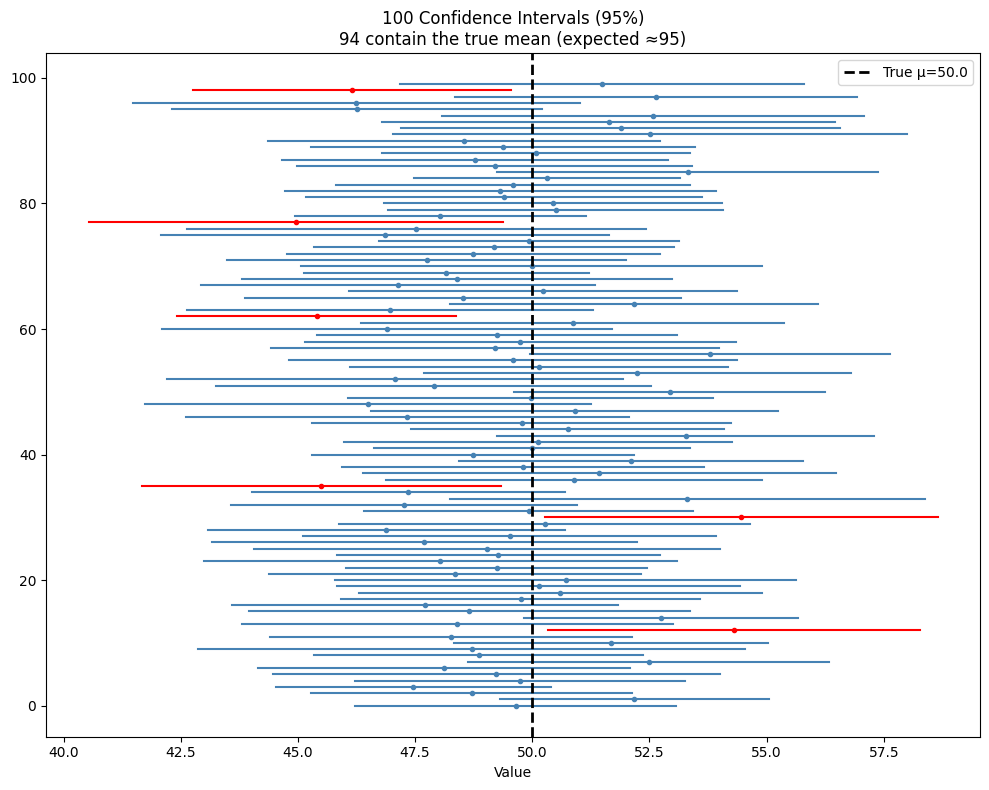

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

def t_confidence_interval(
    sample: np.ndarray, alpha: float = 0.05
) -> tuple[float, float, float]:
    """Returns (mean, lower, upper) for (1-alpha)*100% CI."""
    n    = len(sample)
    mean = sample.mean()
    se   = sample.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    return mean, mean - t_crit * se, mean + t_crit * se

# Demonstrate coverage: 100 intervals, ~95 should contain the true mean
true_mu = 50.0
n_obs   = 25
n_trials = 100

means, lowers, uppers = [], [], []
for _ in range(n_trials):
    sample = rng.normal(true_mu, 10, n_obs)
    m, lo, hi = t_confidence_interval(sample)
    means.append(m); lowers.append(lo); uppers.append(hi)

means   = np.array(means)
lowers  = np.array(lowers)
uppers  = np.array(uppers)
covers  = (lowers <= true_mu) & (true_mu <= uppers)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(n_trials):
    color = 'steelblue' if covers[i] else 'red'
    ax.plot([lowers[i], uppers[i]], [i, i], color=color, lw=1.5)
    ax.plot(means[i], i, 'o', color=color, ms=3)

ax.axvline(true_mu, color='black', lw=2, ls='--', label=f'True μ={true_mu}')
ax.set_xlabel('Value')
ax.set_title(f'100 Confidence Intervals (95%)\n{covers.sum()} contain the true mean (expected ≈95)')
ax.legend()
plt.tight_layout()
plt.show()

In [2]:
# Confidence interval for a difference in means
def ci_difference(
    a: np.ndarray, b: np.ndarray, alpha: float = 0.05
) -> tuple[float, float, float]:
    """Welch CI for mu_b - mu_a."""
    n_a, n_b = len(a), len(b)
    diff = b.mean() - a.mean()
    se   = np.sqrt(a.var(ddof=1)/n_a + b.var(ddof=1)/n_b)
    s_a, s_b = a.var(ddof=1), b.var(ddof=1)
    df   = (s_a/n_a + s_b/n_b)**2 / (
           (s_a/n_a)**2/(n_a-1) + (s_b/n_b)**2/(n_b-1))
    t_c  = stats.t.ppf(1 - alpha/2, df)
    return diff, diff - t_c*se, diff + t_c*se

control   = rng.normal(60, 15, 80)
treatment = rng.normal(67, 18, 80)
diff, lo, hi = ci_difference(control, treatment)

print(f"Difference (treatment - control): {diff:.2f}")
print(f"95% CI: [{lo:.2f}, {hi:.2f}]")
print()
if lo > 0:
    print("CI excludes 0 → statistically significant at α=0.05")
else:
    print("CI includes 0 → not significant at α=0.05")

# Validate with scipy
ci_sp = stats.ttest_ind(treatment, control, equal_var=False)
print(f"\nScipy p-value: {ci_sp.pvalue:.4f} (consistent: p<0.05 ↔ CI excludes 0)")

Difference (treatment - control): 4.26
95% CI: [-0.88, 9.40]

CI includes 0 → not significant at α=0.05

Scipy p-value: 0.1035 (consistent: p<0.05 ↔ CI excludes 0)


## 2. Width of a Confidence Interval

The width of a 95% CI for a mean is:

$$\text{width} = 2 \cdot t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$

To halve the width, you need **4× the sample size**. This is a practical constraint on study design.

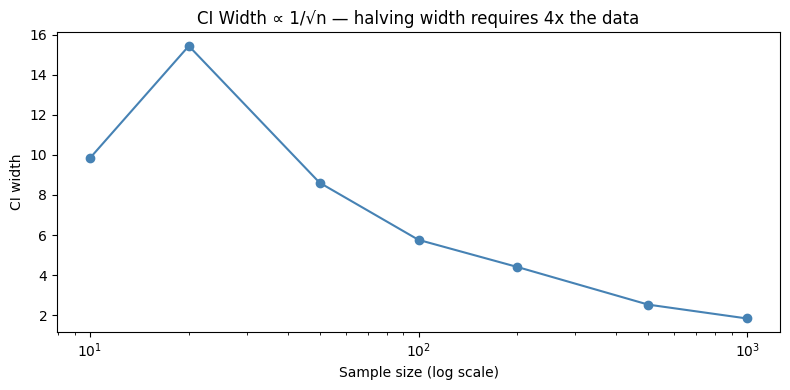

In [3]:
sample_sizes = [10, 20, 50, 100, 200, 500, 1000]
widths = []
for n in sample_sizes:
    s = rng.normal(50, 15, n)
    _, lo, hi = t_confidence_interval(s)
    widths.append(hi - lo)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sample_sizes, widths, 'o-', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Sample size (log scale)')
ax.set_ylabel('CI width')
ax.set_title('CI Width ∝ 1/√n — halving width requires 4x the data')
plt.tight_layout()
plt.show()

## 3. What Comes Next

Confidence intervals apply to single parameters. **ch280 — Correlation** extends inference to the *relationship* between two variables, computing both a point estimate and a CI for the correlation coefficient. The A/B testing framework in **ch285** uses CI-based decision rules that often outperform pure p-value thresholds.